## preprocessing results of the barcode MPRAlm pipeline are investigated here

In [1]:
import pandas as pd

### Barcode per insert of the barcode preprocessing pipeline

In [1]:
import polars as pl
import matplotlib.pyplot as plt

filtered_count_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/bc_preparation/NGN2_filtered_counts_sequences.tsv.gz"

filtered_count = pl.read_csv(filtered_count_path, separator="\t")
filtered_count

variant_id,allele,barcode,DNA1,RNA1,DNA2,RNA2,DNA3,RNA3
str,str,str,i64,i64,i64,i64,i64,i64
"""cardiac_neuro_…","""alt""","""AAAACAAGCATACG…",5,7,3,4,4,13
"""cardiac_neuro_…","""alt""","""AAGTTGATCCCATT…",3,3,2,9,2,8
"""cardiac_neuro_…","""alt""","""AATCCGTCCAAGTC…",12,16,7,18,9,14
"""cardiac_neuro_…","""alt""","""AATGACAACTCACT…",9,29,10,21,15,28
"""cardiac_neuro_…","""alt""","""ACACCGGCAAGGAA…",1,8,5,8,3,13
…,…,…,…,…,…,…,…,…
"""cardiac_neuro_…","""ref""","""TTGCAGCGAGGAAC…",5,8,6,14,6,9
"""cardiac_neuro_…","""ref""","""TTGGCAGCCCGTCG…",1,8,3,7,6,4
"""cardiac_neuro_…","""ref""","""TTGGGCTCCGAGTA…",6,9,4,8,10,9


/tmp/ipykernel_236963/3239511504.py:4: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  bc_number_tbl = dataframe.group_by(["variant_id", "allele"]).count()


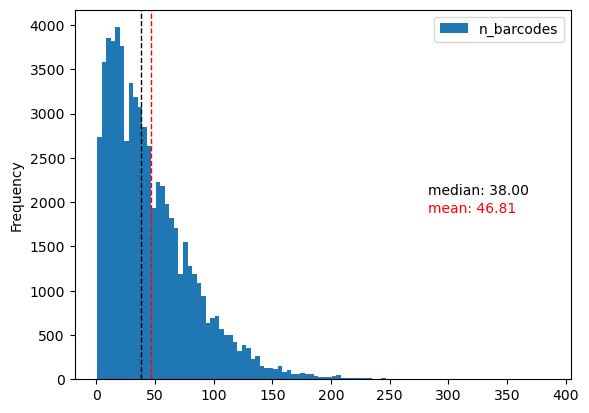

/tmp/ipykernel_236963/3239511504.py:25: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  filtered_count.group_by(["variant_id", "allele"]).count().filter(pl.col("count") > 155)


variant_id,allele,count
str,str,u32
"""cardiac_neuro_…","""ref""",204
"""cardiac_neuro_…","""ref""",233
"""cardiac_neuro_…","""ref""",208
"""cardiac_neuro_…","""alt""",208
"""cardiac_neuro_…","""ref""",173
…,…,…
"""cardiac_neuro_…","""alt""",178
"""cardiac_neuro_…","""ref""",175
"""cardiac_neuro_…","""alt""",202


In [22]:

def plot_barcode_per_insert(dataframe: pl.DataFrame, bins=100):
    """Dataframe with variant_id as column (variant_id, allele, barcode, count of DNA and RNA per replicate)"""
    # show number of barcodes per variant in a histogram and annotate the median and mean number of barcodes
    bc_number_tbl = dataframe.group_by(["variant_id", "allele"]).count()
    bc_number_tbl = bc_number_tbl.select(pl.col("count").alias("n_barcodes"))
    bc_number_tbl = bc_number_tbl.sort("n_barcodes")
    bc_number_tbl = bc_number_tbl.to_pandas()
    bc_number_tbl.plot.hist(bins=bins)
    # annotate the mean and median value as text in the right upper corner below the legend

    plt.axvline(bc_number_tbl.median().values[0], color='k', linestyle='dashed', linewidth=1)
    plt.axvline(bc_number_tbl.mean().values[0], color='r', linestyle='dashed', linewidth=1)
    # get mean frequency of barcodes per variant
    ylim = plt.gca().get_ylim()
    xlim = plt.gca().get_xlim()

    # add text to the plot (half y-axis, 0.8 x-axis) with same color
    plt.text(xlim[1]*0.7, ylim[1]*0.5, f"median: {bc_number_tbl.median().values[0]:.2f}", color='k')
    plt.text(xlim[1]*0.7, ylim[1]*0.45, f"mean: {bc_number_tbl.mean().values[0]:.2f}", color='r')

    plt.show()
    
plot_barcode_per_insert(filtered_count, 100)

filtered_count.group_by(["variant_id", "allele"]).count().filter(pl.col("count") > 155) # 977

#### Now investigate the standard_mpralm_input_NGN2.tsv (input for barcode MPRAlm)

In [19]:
# filter polars dataframe "alt" in allele column
mpralm_alt = bc_mpralm.filter(pl.col("allele") == "alt")
mpralm_ref = bc_mpralm.filter(pl.col("allele") == "ref")

# plot_barcode_per_insert(mpralm_ref, 100)
mpralm_ref.group_by(["variant_id"]).count().filter(pl.col("count")>155) # len: 2_761

/tmp/ipykernel_236963/2733436971.py:6: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  mpralm_ref.group_by(["variant_id"]).count().filter(pl.col("count")>155)


variant_id,count
str,u32
"""cardiac_neuro_…",164
"""cardiac_neuro_…",163
"""cardiac_neuro_…",166
"""cardiac_neuro_…",167
"""cardiac_neuro_…",162
…,…
"""cardiac_neuro_…",162
"""cardiac_neuro_…",167
"""cardiac_neuro_…",167


/tmp/ipykernel_236963/1889246410.py:4: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  bc_number_tbl = dataframe.group_by(["variant_id", "allele"]).count()


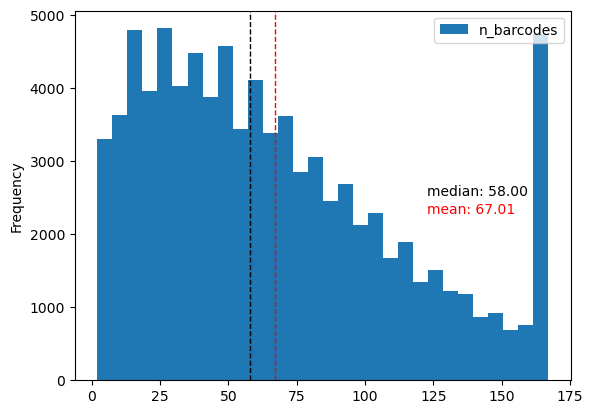

In [11]:
# bc_mpralm_input_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/preprocess/standard_mpralm_input_NGN2.tsv'
# bc_mpralm_input_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/preprocess/lowConfig_mpralm_input_NGN2.tsv'
# bc_mpralm = pl.read_csv(bc_mpralm_input_path, separator="\t")


plot_barcode_per_insert(bc_mpralm, 30)

In [5]:
bc_count = bc_mpralm.group_by(["variant_id", "allele"]).count()
bc_count["count"].max()

/tmp/ipykernel_236963/3294884484.py:1: DeprecationWarning: `count` is deprecated. It has been renamed to `len`.
  bc_count = bc_mpralm.group_by(["variant_id", "allele"]).count()


167

In [ ]:
# check dna and rna specific: should look the same: 
dna_bcMPRAlm = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/results/preprocess/standard_mpralm_bc_dna_input_NGN2.tsv'

In [4]:
## final output (counts and sequences)
# /data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/NGN2_counts_sequences.tsv.gz
counts_sequences = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/NGN2_counts_sequences.tsv.gz'

counts_sequences_df = pd.read_csv(counts_sequences, sep='\t', header=None)
counts_sequences_df.columns = ["variant_id", "allele", "barcode", "DNA1", "RNA1", "DNA2", "RNA2", "DNA3", "RNA3"]
counts_sequences_df

,variant_id,allele,barcode,DNA1,RNA1,DNA2,RNA2,DNA3,RNA3
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,ACCAGGCGCATGCGC,1,1,1,3,2,5
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,CTAGTCCTATGGCCG,1,1,1,5,1,7
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,GCGACGGGGATATGG,1,12,3,2,3,4
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,GTGGTTTGCTCGTTG,1,12,5,6,6,3
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,TTAAGATCACTTGTC,1,5,3,4,2,2
...,...,...,...,...,...,...,...,...,...
3497662,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TAGTTTCTGGGCATG,8,15,7,15,4,12
3497663,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,GGAAGACGCCCGGAG,8,24,6,20,12,22
3497664,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,CTAACTCAAGCGTGC,8,5,2,15,4,14
3497665,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,AAGGGATAAAAGCCG,9,19,5,12,7,15


In [5]:
counts_sequences_df["allele"].value_counts()
# allele
# alt    1970324
# ref    1527343

allele
alt    1970324
ref    1527343
Name: count, dtype: int64

### Investigate each step of the MPRAlm pipeline and how many variants get lost
- variant_region_map
- how many sequences of that are still found nach filtering of MPRAsnakeflow


In [6]:
import pandas as pd
# std_oligo_sort = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/new_assignment_NGN2_seqs_to_oligos_sorted.tsv.gz'
# std_oligo_sort_df = pd.read_csv(std_oligo_sort, sep='\t', header=None) # 92748 
# std_oligo_sort_df

# std_filtered_counts = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/new_assignment_NGN2_filtered_counts_sequences.tsv.gz'
# std_filtered_counts_df = pd.read_csv(std_filtered_counts, sep='\t')
# std_filtered_counts_df # 3649962  

std_new_filtered_counts = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/standard_NGN2_filtered_counts_sequences.tsv.gz'
std_new_filtered_counts_df = pd.read_csv(std_new_filtered_counts, sep='\t')
std_new_filtered_counts_df # 3531737 

std_new_filtered_counts_df.variant_id.nunique() # 42129


42129

##### Low config: 
- uses assignment and counts
    - `/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/assigned_counts/assignmentFixDuplicates/NGN2_3.merged.config.lowConfig.tsv.gz`
    - `/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/80K_MPRA/design/variant_region_map_deduplicated.tsv.gz`
- `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_counts_per_bc_sorted.tsv.gz`
- `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_seqs_to_oligos_sorted.tsv.gz`
- `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_counts_sequences.tsv.gz`
- `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_single_seqs.tsv` (820 rows vorher 813 rows) (this are the sequences which cannot be matched)
- `/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_filtered_counts_sequences.tsv.gz` # 42584 unique ref; 42596 unique alt

In [200]:
# variant_region_map:
# var_reg_map = '/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/80K_MPRA/design/variant_region_map_deduplicated.tsv.gz'
# var_reg_map_df = pd.read_csv(var_reg_map, sep='\t')
# var_reg_map_df
# var_reg_map_df["Variant"].nunique() # 45737
# var_reg_map_df["REF_ID"].nunique() # 18572
# var_reg_map_df["ALT_ID"].nunique() # 46374

ValueError: If using all scalar values, you must pass an index

In [172]:
# counts: NGN2_3.merged.config.lowConfig.tsv.gz
coun1 = '/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/lowConfig_bwa/assigned_counts/assignmentFixDuplicates/NGN2_3.merged.config.lowConfig.tsv.gz'
count1_df = pd.read_csv(coun1, sep='\t', header=None)
count1_df.columns = ["barcode", "DNA_count", "RNA_count"]
count1_df # 5488208

,barcode,DNA_count,RNA_count
0,AAAAAAAAAAACGTC,3,2
1,AAAAAAAAAACAAGT,0,1
2,AAAAAAAAAAGCTGG,4,5
3,AAAAAAAAAAGTGCA,1,1
4,AAAAAAAAAATCCTA,1,4
...,...,...,...
5488203,TTTTTTTTTGTTAAA,5,4
5488204,TTTTTTTTTTCTGGC,2,1
5488205,TTTTTTTTTTGACCG,5,10
5488206,TTTTTTTTTTGACGA,2,5


In [173]:
# all counts per barcode  
low_counts_per_bc = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_counts_per_bc_sorted.tsv.gz'
low_counts_per_bc_df = pd.read_csv(low_counts_per_bc, sep='\t', header=None)
low_counts_per_bc_df.columns = ["barcode", "ID", "DNA_count_1", "RNA_count_1", "DNA_count_2", "RNA_count_2", "DNA_count_3", "RNA_count_3"]
low_counts_per_bc_df # 5169860 
# sorum, weil laut rule: /data/gpfs-1/users/kisa11_c/work/coding/standardMPRAsnakeflow/workflow/rules/counts.smk erst dna und dann rna in counts

,barcode,ID,DNA_count_1,RNA_count_1,DNA_count_2,RNA_count_2,DNA_count_3,RNA_count_3
0,CTAGCACGCGCGAGC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0,1,0,2,1,3
1,GCATTAAGGCAACTC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0,1,0,4,2,2
2,CTGTGTCGATGACAC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0,1,1,1,1,0
3,GCGTTACAGTCCTTC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0,1,2,6,0,9
4,CAGCTGGTGTGATGC,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0,12,4,10,1,6
...,...,...,...,...,...,...,...,...
5169855,ACTAGTTCTAGAAAA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,7,2,4,11,2,6
5169856,GTATCCGATCTGACA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,7,9,4,9,4,10
5169857,TTTTTAATCGGGTTC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,8,12,3,13,7,8
5169858,TACGGACTATCACAT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,8,19,8,18,4,14


In [190]:
# read seqs to olios sorted: each line of the variant_region_map is split: alt and ref are two lines $1, $3 + $1, $4
# low_seq_oligo_sort = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_seqs_to_oligos_sorted.tsv.gz'
# low_seq_oligo_sort_df = pd.read_csv(seq_oligo_sort, sep='\t', header=None)
# low_seq_oligo_sort_df.columns = ["variant_id", "ID", "allele"]
# low_seq_oligo_sort_df # 92748  / 2 = 46374

# low_count_seqs = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_counts_sequences.tsv.gz'
# low_count_seqs_df = pd.read_csv(low_count_seqs, sep='\t', header=None)
# low_count_seqs_df.columns = ["ID", "allele", "barcode", "DNA1", "RNA1", "DNA2", "RNA2", "DNA3", "RNA3"]
low_count_seqs_df # 5842405

# the filtering is that we take the non matching lines (we wrote the single occuring sequences)
# investigate: single sequences: take ID+allele (unique) => take $1 => sort + uniq -c |  awk '$1 != 2' |  awk '{print $2}' > $single_seqs
# low_count_seqs_df["ID_allele"] = low_count_seqs_df["ID"] + low_count_seqs_df["allele"]
# low_count_seqs_df["ID_allele"].value_counts()  # 85984




85984

In [208]:
low_filtered_counts = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/bc_tradeoff/lowConfig_NGN2_filtered_counts_sequences.tsv.gz'
low_filtered_counts_df = pd.read_csv(low_filtered_counts, sep='\t')
low_filtered_counts_df # 5827835  

,variant_id,allele,barcode,DNA1,RNA1,DNA2,RNA2,DNA3,RNA3
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AAAACAAGCATACGG,4,13,3,4,5,7
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AACGCTGACCGGGAC,1,4,0,4,0,8
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AAGTTGATCCCATTC,2,8,2,9,3,3
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AATCCGTCCAAGTCG,9,14,7,18,12,16
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AATGACAACTCACTT,15,28,10,21,9,29
...,...,...,...,...,...,...,...,...,...
5827830,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGCAGCGAGGAACC,6,9,6,14,5,8
5827831,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGGCAGCCCGTCGC,6,4,3,7,1,8
5827832,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGGGCTCCGAGTAG,10,9,4,8,6,9
5827833,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGTGTATCCCTGGA,2,14,3,11,5,15


In [ ]:
low_count_seqs_df[]
# cut -f 1 | sort | uniq -c |  awk '$1 != 2' |  awk '{print $2}' > $single_seqs

In [210]:
low_filtered_counts_df.variant_id.nunique() # 42598
# how many with alt in allele
# low_filtered_counts_df[low_filtered_counts_df.allele == 'alt'] # 2913688 
# low_filtered_counts_df[low_filtered_counts_df.allele == 'alt'].variant_id.nunique() # 42596 (filtering von MPRAsnakeflow: 46374 - 42596 = 3778)
# low_filtered_counts_df[low_filtered_counts_df.allele == 'ref'] # 2914147  
# low_filtered_counts_df[low_filtered_counts_df.allele == 'ref'].variant_id.nunique() # 42584  

42598

### Pia: we have barcodes assigned to two variants in NGN2_counts_sequences.tsv.gz
- Question: is the assignment correct?

In [6]:
# load the used assignment file 
assignment_file = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/experiment/results/experiments/run1counts_run2Assignment_NoDupAss/assignment/assignmentFixDuplicates.tsv.gz"
assignement_df = pd.read_csv(assignment_file, sep='\t', header=None)
assignement_df.columns = ["barcode", "oligo_id", "informations", "assignment_number"] # 7078311 rows
curr_file = "assignement_df"
# identify if the barcode column is unique or not
print(f"Check if barcode column in {curr_file} is unique")
if assignement_df["barcode"].is_unique: # True
    print("barcode column is unique")

In [11]:
assignement_df

,barcode,oligo_id,informations,assignment_number
0,AAAAAAAAAAACGTC,GC_Vista:eye;fb;hb;mb_hs1644_vistaElementContr...,16;270M;NM:i:0;MD:Z:270;60,5/5
1,AAAAAAAAAACAAGT,cardiac_neuro_cava_random:ALT_ZBTB20|ENSG00000...,16;270M;NM:i:0;MD:Z:270;6,7/7
2,AAAAAAAAAACACCA,cardiac_neuro_cava_random:ALT_FTO|ENSG00000140...,16;270M;NM:i:0;MD:Z:270;6,10/10
3,AAAAAAAAAACCTCG,cardiac_neuro_cava_random:REF_FKRP|ENSG0000018...,16;270M;NM:i:0;MD:Z:270;6,7/7
4,AAAAAAAAAAGCTGG,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,16;270M;NM:i:0;MD:Z:270;6,8/8
...,...,...,...,...
7078306,TTTTTTTTTTGACGA,cardiac_neuro_cava_random:ALT_ACTN2|ENSG000000...,16;270M;NM:i:0;MD:Z:270;6,11/11
7078307,TTTTTTTTTTGCACA,cardiac_neuro_cava_random:ALT_CARD11|ENSG00000...,16;270M;NM:i:0;MD:Z:270;6,25/26
7078308,TTTTTTTTTTGCACC,cardiac_neuro_cava_random:ALT_KRAS|ENSG0000013...,16;214M1I56M;NM:i:1;MD:Z:270;5,6/7
7078309,TTTTTTTTTTGCTAA,cardiac_neuro_cava_random:REF_NR4A2|ENSG000001...,16;270M;NM:i:0;MD:Z:270;6,6/6


#### Question: Why is the NGN2_counts_sequences.tsv.gz file larger than NGN2_counts_per_bc_sorted.tsv.gz

In [12]:
# idea: load the NGN2_counts_per_bc_sorted.tsv.gz and find duplicated barcodes
counts_per_bc = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/bc_tradeoff/NGN2_counts_per_bc_sorted.tsv.gz"
counts_per_bc_df = pd.read_csv(counts_per_bc, sep='\t', header=None) # 3482468 rows
counts_per_bc_df.columns = ["barcode", "oligo_id", "DNA1", "RNA1", "DNA2", "RNA2", "DNA3", "RNA3"]

curr_file = "counts_per_bc"

In [14]:
counts_per_bc_df

In [15]:
print(f"Check if barcode column of {curr_file} is unique")
if counts_per_bc_df["barcode"].is_unique: # True
    print("barcode column is unique")

Check if barcode column of {curr_file} is unique
barcode column is unique


In [16]:
count_sequence = "/data/gpfs-1/groups/ag_kircher/work/MPRA/IGVF_Y1_design/projects/bc_tradeoff/NGN2_counts_sequences.tsv.gz"
count_sequence_df = pd.read_csv(count_sequence, sep='\t', header=None) # 3497667 rows
count_sequence_df.columns = ["variant_id", "allele", "barcode", "DNA1", "RNA1", "DNA2", "RNA2", "DNA3", "RNA3"]
curr_file = "joint_count_sequences"

In [17]:
count_sequence_df

,variant_id,allele,barcode,DNA1,RNA1,DNA2,RNA2,DNA3,RNA3
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AAAACAAGCATACGG,5,7,3,4,4,13
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AAGTTGATCCCATTC,3,3,2,9,2,8
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AATCCGTCCAAGTCG,12,16,7,18,9,14
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,AATGACAACTCACTT,9,29,10,21,15,28
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,alt,ACACCGGCAAGGAAT,1,8,5,8,3,13
...,...,...,...,...,...,...,...,...,...
3497662,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGCAGCGAGGAACC,5,8,6,14,6,9
3497663,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGGCAGCCCGTCGC,1,8,3,7,6,4
3497664,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGGGCTCCGAGTAG,6,9,4,8,10,9
3497665,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGTGTATCCCTGGA,5,15,3,11,2,14


In [23]:
count_sequence_df["variant_id"].is_unique # False

False

In [21]:
# print(f"Check if barcode column of {curr_file} is unique")
# if count_sequence_df["barcode"].is_unique: # True
#     print("barcode column is unique")
# else: 
#     print("barcode column is not unique")

# investigate barcodes matching to multiple oligos
# find duplicated barcodes and show their variant ids
duplicated_barcodes = count_sequence_df[count_sequence_df.duplicated(['barcode'], keep=False)]
duplicated_barcodes


,variant_id,allele,barcode,DNA1,RNA1,DNA2,RNA2,DNA3,RNA3
177,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,ref,AACTTTATCAATCAG,3,16,1,5,4,9
178,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,ref,AATCCATCCGACTGG,2,14,5,9,3,13
179,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,ref,AATTTGCTACGCTTC,10,28,12,23,15,20
180,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,ref,ACAAGCTCCATGGCG,7,16,4,20,5,12
181,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,ref,AGGAAAATACGGCTG,2,7,6,5,1,6
...,...,...,...,...,...,...,...,...,...
3497662,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGCAGCGAGGAACC,5,8,6,14,6,9
3497663,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGGCAGCCCGTCGC,1,8,3,7,6,4
3497664,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGGGCTCCGAGTAG,6,9,4,8,10,9
3497665,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,ref,TTGTGTATCCCTGGA,5,15,3,11,2,14


In [25]:
# check if all barcodes have a count > 1 => yes
(duplicated_barcodes["barcode"].value_counts() > 1).all() # True

True

In [26]:
# duplicated_barcodes_df has 1156879 rows how many unique barcodes are there?
duplicated_barcodes["barcode"].nunique() # 407946 so 1165879 / 407946 = 2.86 => each barcode is assigned to 2.86 other barcodes

407946

#### Investigate if pias data is correct

In [29]:
pia_count_sequence = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/ProximalPromoter/projects/tt_analysis/malacoda_input_HepG2.tsv.gz"
pia_count_sequence_df = pd.read_csv(pia_count_sequence, sep='\t', header=0) #
pia_count_sequence_df

,variant_id,allele,barcode,DNA1,RNA1,DNA2,RNA2,DNA3,RNA3
0,Arensbergen_rs1004571_chr20:45278169A>G,alt,ATTGAAACGAAAGAA,2,1,5,3,1,4
1,Arensbergen_rs1004571_chr20:45278169A>G,alt,GCGATGAGCATGATA,5,12,8,12,6,22
2,Arensbergen_rs1004571_chr20:45278169A>G,alt,TACACGGGTGAGAAG,2,7,2,4,3,1
3,Arensbergen_rs1004571_chr20:45278169A>G,alt,TCAAAAAAAAGAATA,2,4,6,3,2,3
4,Arensbergen_rs1004571_chr20:45278169A>G,alt,TGTACTAAAGTGGTA,3,4,8,14,1,1
...,...,...,...,...,...,...,...,...,...
6552198,SaturationMutagenesis_TERT_28_C.T_chr5:1295240G>A,ref,GGGATCATATCCATC,11,37,6,23,7,19
6552199,SaturationMutagenesis_TERT_28_C.T_chr5:1295240G>A,ref,GTCATGCGAAGTCAG,5,12,11,4,6,5
6552200,SaturationMutagenesis_TERT_28_C.T_chr5:1295240G>A,ref,GTTTACTTTGTTGAT,11,4,9,2,2,2
6552201,SaturationMutagenesis_TERT_28_C.T_chr5:1295240G>A,ref,TAAAAATTGTTGAAT,7,8,8,3,1,2


In [ ]:
counts_per_bc = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/ProximalPromoter/projects/tt_analysis/HepG2_counts_per_bc.tsv.gz"